# Assignment 3: Detection

### Imports

In [128]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

### Problem 1

sequence x[n]: [-1.00015848  0.06270414 -0.81079844 ...  1.64719239  0.5900194
  0.66463949]

Size of sequence x[n]: 10000

plot of 100 samples from x[n]



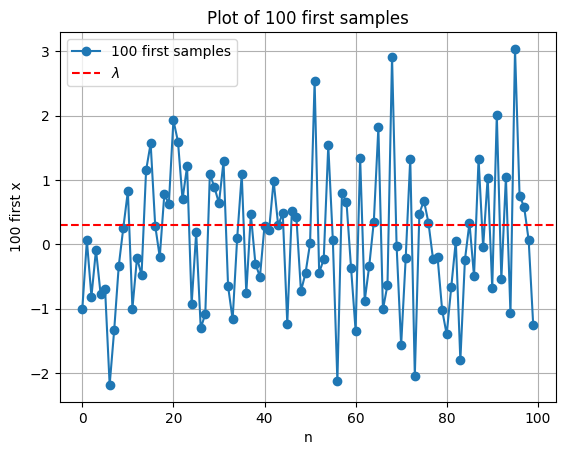

Q1: How many samples exceed the threshold?
A1: Number of samples exceeding threshold is 39



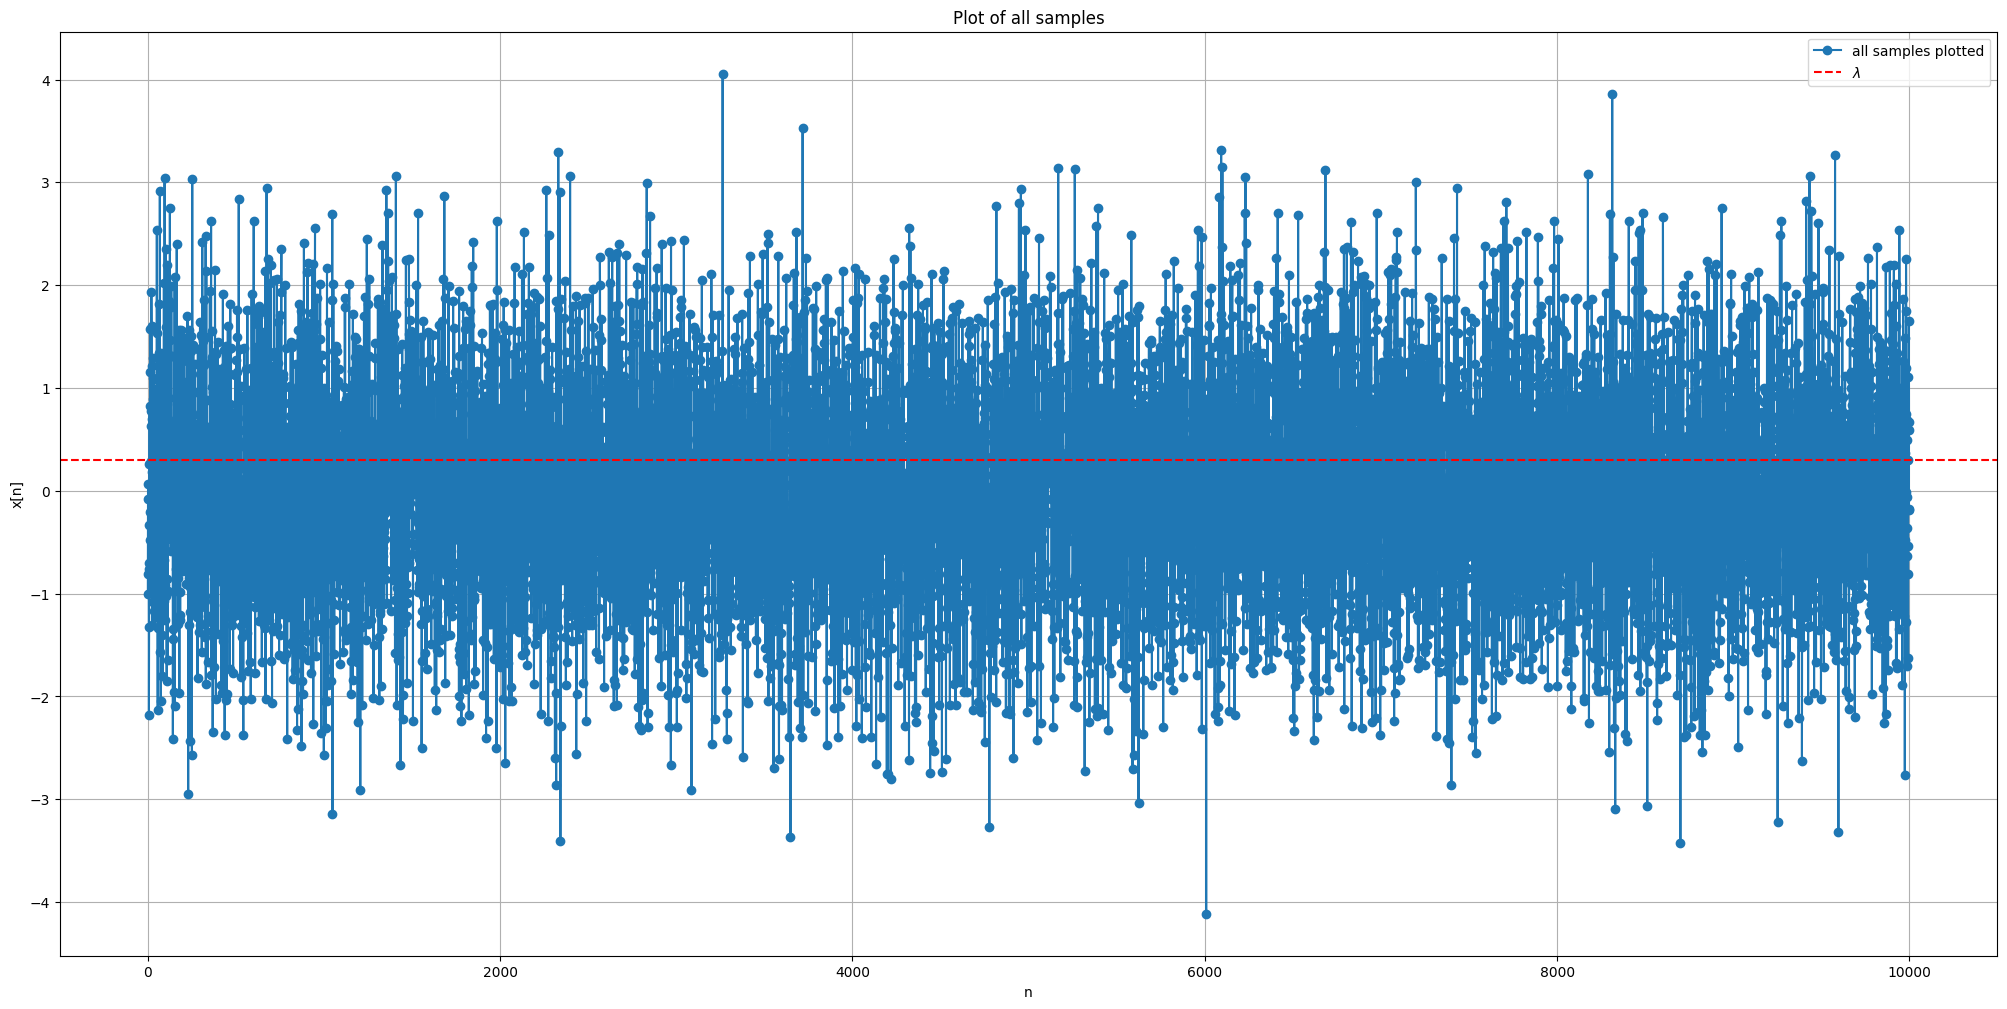

Q2: What is the fraction that exceeds the threshold? 
A2: Fraction that exceeds threshold is 0.3821

Theoretical value: lambda = 0.3 vs. Simulated value lambda_sim = 0.3821

theoretical value more corrent: 0.38208857781104744


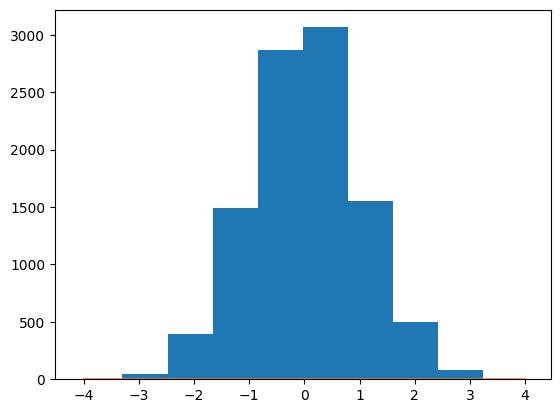

In [ ]:
# Defining constants
N=10**4
mu=0
sigma_squared=1
sigma=np.sqrt(sigma_squared)
number_samples = 100
lambd=0.3

# Generating sequence x[n]
x = np.random.normal(mu, sigma, N)
print(f"sequence x[n]: {x}\n")
print(f"Size of sequence x[n]: {len(x)}\n")

# Plotting 100 samples together with a constant threshold lambda = 0.3
print("plot of 100 samples from x[n]\n")
n = np.arange(number_samples)
x_100=x[:number_samples]

plt.title('Plot of 100 first samples')
plt.plot(n, x_100, label='100 first samples', marker='o')
plt.axhline(lambd, color='red', label=r'$\lambda$', linestyle='--')
plt.xlabel('n')
plt.ylabel('100 first x')
plt.legend()
plt.grid()
plt.show()

# Q1: How many samples exceed the threshold? 
print("Q1: How many samples exceed the threshold?")
sample_over_threshold_100=[]
for sample_100 in x_100:
    if sample_100 > lambd:
        sample_over_threshold_100.append(sample_100)
# count_100 = np.sum(x_100 > lambda_)
print(f'A1: Number of samples exceeding threshold is {len(sample_over_threshold_100)}\n')


# Now considering all sample values, first the plot
n_true = np.arange(len(x))

plt.figure(figsize=(25, 12))
plt.title('Plot of all samples')
plt.plot(n_true, x, label='all samples plotted', marker='o')
plt.axhline(lambd, color='red', label=r'$\lambda$', linestyle='--')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.legend()
plt.grid()
plt.show()

# Q2: What is the fraction that exceeds the threshold? 
print("Q2: What is the fraction that exceeds the threshold? ")
sample_over_threshold=[]
for sample in x:
    if sample > lambd:
        sample_over_threshold.append(sample)
# fraction_sim = np.sum(x > lambda_) / N
print(f'A2: Fraction that exceeds threshold is {len(sample_over_threshold)/len(x)}\n')

# Comparing to the theoretical value. 
fraction_theory = 1 - sp.stats.norm.cdf(lambd, loc=mu, scale=sigma)
print(f"Theoretical value: lambda = {lambd} vs. Simulated value lambda_sim = {len(sample_over_threshold)/len(x)}\n")
print(f"Theoretical value more correct: {fraction_theory}")

# Plotting histogram, true PDF, etc.
x_plots = np.linspace(-4, 4, 10000)

def normal(x_plots):
    return (1 / np.sqrt(2*np.pi*sigma_squared)) * np.exp((-0.5) * (x_plots - mu)**2 / sigma_squared)

plt.title("Histogram and true PDF")
plt.hist(x, bins=50, density=True, label="Histogram")
plt.plot(x_plots, sp.stats.norm.pdf(x_plots, mu, sigma), label='True PDF')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Constants
N = 10**4
mu = 0
sigma2 = 1
sigma = np.sqrt(sigma2)
lambda_ = 0.3
number_samples = 100

# Generate x[n] ~ N(0,1)
x = np.random.normal(mu, sigma, N)

# First 100 samples
x_100 = x[:number_samples]
n = np.arange(number_samples)

# Count how many of first 100 exceed threshold
count_100 = np.sum(x_100 > lambda_)

print(f"Number of samples above threshold among first 100 samples: {count_100}")

# Fraction of all samples exceeding threshold
fraction_sim = np.sum(x > lambda_) / N
print(f"Fraction of all samples exceeding threshold: {fraction_sim:.4f}")

# Theoretical probability P(X > lambda)
fraction_theory = 1 - norm.cdf(lambda_, loc=mu, scale=sigma)
print(f"Theoretical value: {fraction_theory:.4f}")

# Plot first 100 samples with threshold
plt.figure(figsize=(10, 5))
plt.plot(n, x_100, label='First 100 samples')
plt.axhline(lambda_, color='red', linestyle='--', label=r'Threshold $\lambda = 0.3$')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title('First 100 Gaussian samples with threshold')
plt.legend()
plt.grid(True)
plt.show()

# Histogram + true PDF
x_axis = np.linspace(-4, 4, 1000)

plt.figure(figsize=(10, 5))
plt.hist(x, bins=50, density=True, alpha=0.6, label='Histogram')
plt.plot(x_axis, norm.pdf(x_axis, loc=mu, scale=sigma), linewidth=2, label='True PDF')
plt.axvline(lambda_, color='red', linestyle='--', label=r'$\lambda = 0.3$')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Histogram and true PDF')
plt.legend()
plt.grid(True)
plt.show()